# Task 1: Identifying the Prediction Target

The target variable for the assignment is "y"

The goal of the bank is to determine if a client will subscribe to a term deposit. The variable "y" is a binary variable which indicates if a client has subscribed to a term deposit or not. This variable is describing the outcome of the campaign, whereas the others are either attributes of clients or campaign information.

One variable that could superficially appear to be a target is "duration", the duration of the last contact with the customer. The duration is not known before the call is performed and is highly impactful on the final outcome. Finally after the call the outcome is known, they either agreed to subscribe or they didn't.

Another variable that could appear to be a target is "poutcome", the outcome of the previous marketing campaign not the current one. Superficially it may seem like the target variable.

# Task 2: Data Loading and Exploration


## Loading the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("bank-additional.csv", sep=';')
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()



Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## Structure of dataset

In [ ]:
#See data types
#There are no explicit NaN values.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Number of Observations: 4119
Number of features: 20 ("y" is the target and doesn't count as a feature)

Data types: 
- Numerical: "age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "euribor3m", "nr.employed"
- Categorical: "job", "marital", "education", "default", "housing", "loan, "contact", "month", "day_of_week", "poutcome"
- Target (but also categorical): "y"

In [30]:
#Summary statistics for numerical variables
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [31]:
#See value counts for target variable
df['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [32]:
#See relative frequencies for target variable
df['y'].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Target variable distribution
The target "y"  is very imbalanced.
No: 3668 - 89.1%
Yes: 451 - 10.9%

This could lead to potential problems as a model could achieve high accuracy by just predicting "no". We will have to value other measurements when making and training the model.

In [69]:
df['default'].value_counts(normalize=True)

default
no         0.804807
unknown    0.194950
yes        0.000243
Name: proportion, dtype: float64

## Explicit and Implicit missing values

In [39]:
implicit_unknown_counts = (df == 'unknown').sum()
implicit_999_counts = (df == 999).sum()

print("\n'Unknown' values per column:\n", implicit_unknown_counts[implicit_unknown_counts > 0])

print("\n'999' values per column:\n", implicit_999_counts[implicit_999_counts > 0])


'Unknown' values per column:
 job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64

'999' values per column:
 duration       1
pdays       3959
dtype: int64


### Implicit missing values summary

There are no explicit missing values, however there are many implicit missing values

**Treat as missing**
- "Unknown": job (39), marital (11), education (167), default (803), housing (105), loan (105)
- "999": pdays (3959)

**Ignored**
- "999" in duration (1)

The value in duration refers to the amount of seconds, not an unknown value so we must ignore/discard this result from the missing values

## Visualization of Distributions

Visualization of distributions:

Numerical: "Duration" and "age"

Categorical: "has_previous" and "job"

Although "previous" is a numerical value i have converted it into a categorical value to see if having been contacted before (y or n) has an effect on potential clients.

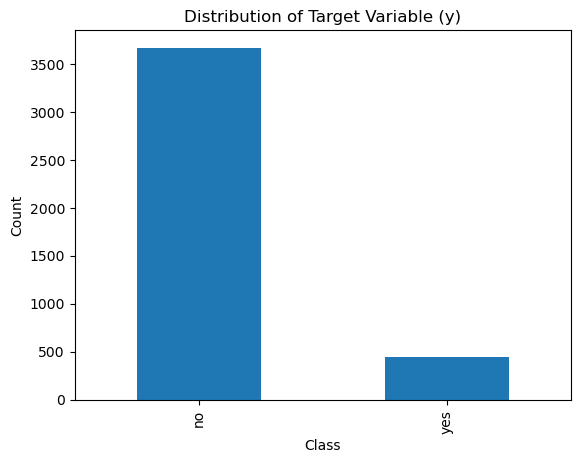

In [33]:
#Visualize distribution of target variable
df['y'].value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (y)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Numerical Variable Distributions

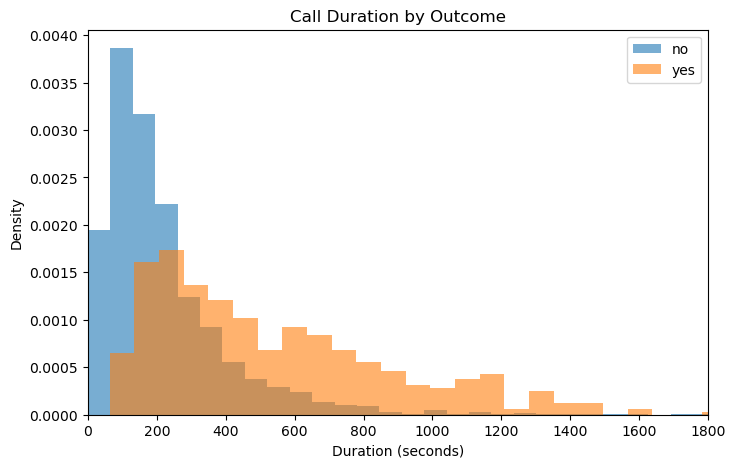

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["duration"],
         bins=50, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["duration"],
         bins=50, alpha=0.6, label="yes", density=True)

plt.title("Call Duration by Outcome")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1800)

plt.show()

Histogram comparing call duration for customers who subscribed vs. those who did not

Longer call durations are often associated with successful subscriptions, so we can expect to see a right-skewed distribution for the "yes" class and a more left-skewed distribution for the "no" class.

This feature shouldn't be included as the outcome is known after the call ends therefore including it in the model would cause data leakage.


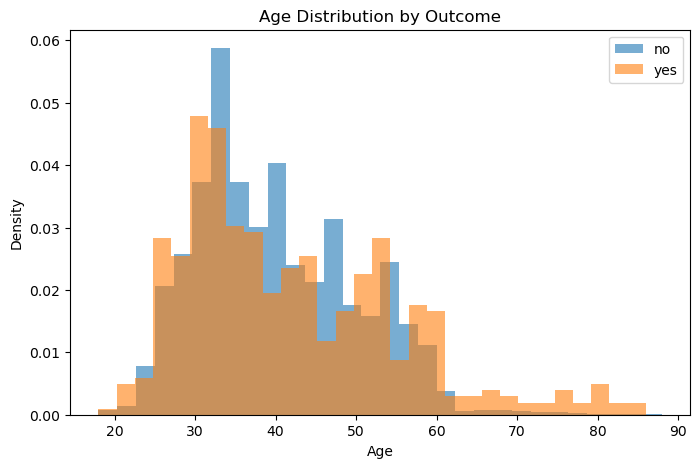

In [ ]:
#Histogram comparing age distribution for customers who subscribed vs. those who did not
#Age can influence subscription likelihood, with certain age groups potentially more inclined to subscribe.
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["age"],
         bins=30, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["age"],
         bins=30, alpha=0.6, label="yes", density=True)

plt.title("Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

### Categorical Variable Distributions

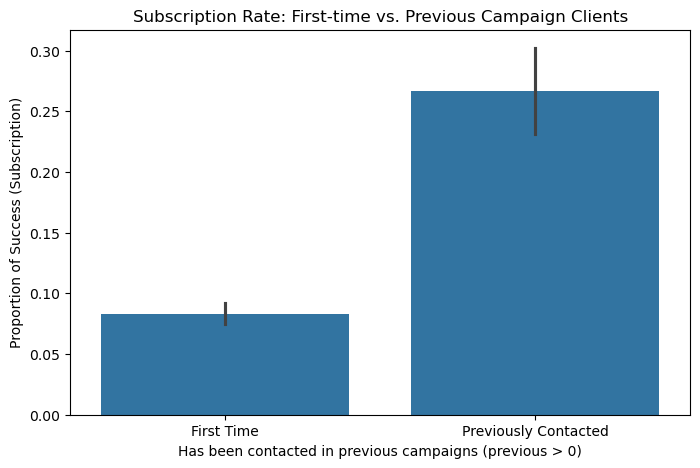

In [ ]:
#Barplot comparing subscription rates for clients with and without previous campaign contacts
#Clients who have been contacted in previous campaigns may have a higher subscription rate due to increased familiarity with the bank's offerings, while first-time contacts may have a lower subscription rate.

df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
df['has_previous'] = df['previous'] > 0

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='has_previous', y='y_numeric')

plt.title('Subscription Rate: First-time vs. Previous Campaign Clients')
plt.ylabel('Proportion of Success (Subscription)')
plt.xlabel('Has been contacted in previous campaigns (previous > 0)')
plt.xticks([0, 1], ['First Time', 'Previously Contacted'])
plt.show()

# Clean up the temporary column after plotting
df.drop(columns=['y_numeric', 'has_previous'], inplace=True)

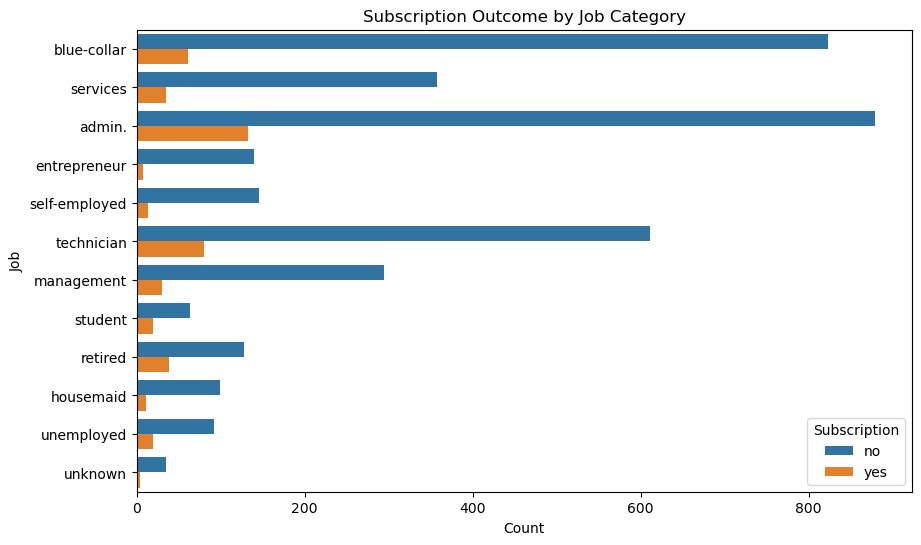

In [ ]:
#Barplot comparing subscription rates across different job categories
#Certain job categories may have higher subscription rates due to factors like income stability, financial literacy, or lifestyle, which can influence their likelihood to subscribe to a term deposit.

plt.figure(figsize=(10,6))

sns.countplot(data=df, y='job', hue='y')

plt.title("Subscription Outcome by Job Category")
plt.xlabel("Count")
plt.ylabel("Job")
plt.legend(title="Subscription")
plt.show()

## Special Consideration Variables

One variable that needs special consideration is "duration". It is not available at prediction time and must be discarded from the feature set to avoid data leakage.

Another variable that needs special consideration is "pdays", 96.1% of rows have the value set as "999", meaning the customers have not been previously contacted before or the data has not been saved and is unknown. Instead of treating this variable as continuous it should be converted into a categorical variable of was previously contacted (similarly to "previous")

Finally we have to consider the variable "default", 19.5% of results have implicit missing values. very few clients will admit to being in default, therefore causing the variable to have near zero variance. This could be a potential variable to exclude from the feature set as well.


# Task 3: Task Ordering